In [54]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import matplotlib.dates as mdates
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
import json
import geopandas as gpd

In [55]:
import yaml
from pathlib import Path

with open('../config.yaml') as _f:
    cfg = yaml.safe_load(_f)

REPO_ROOT = Path.cwd().parent

for section in cfg['paths']:
    cfg['paths'][section] = str(REPO_ROOT / cfg['paths'][section])
for section in cfg['output']:
    cfg['output'][section] = str(REPO_ROOT / cfg['output'][section])

FIGURES_DIR = Path(cfg['output']['figures_dir'])
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Load Ocean Reanalysis Models

In [56]:
# TOPAZ Arctic Ocean Reanalysis
def load_arctic_reanalysis(glacier):
    ocean_reanalysis = xr.open_dataset(cfg['paths']['topaz4_store_file'])
    
    lat, lon = ocean_reanalysis['latitude'].values, ocean_reanalysis['longitude'].values
    max_depth = ocean_reanalysis['model_depth'].max().values
    print(f'Max depth: {max_depth} m')
    
    # Calculate depth-weighted mean temperature
    depth_weighted_temp = ocean_reanalysis.sel(depth=slice(max_depth - 300, max_depth))
    avg_temp = depth_weighted_temp['thetao'].mean(dim='depth')
    
    average_temperature_df = avg_temp.to_dataframe(name='thetao').reset_index()
    average_temperature_df = average_temperature_df.set_index('time')
    
    # Monthly resampling
    average_temperature_df = average_temperature_df.resample('MS').mean()
    
    return average_temperature_df

average_temperature_df = load_arctic_reanalysis('Store Glacier')
print(f"TOPAZ data loaded: {len(average_temperature_df)} monthly records")
print(f"Date range: {average_temperature_df.index.min()} to {average_temperature_df.index.max()}")

# ASTE Regional Arctic Model
aste_ds = xr.open_dataset('../data/reanalysis/ASTE_theta_timeseries.nc')
aste_k_depth_values = pd.read_csv('../data/reanalysis/ASTE_k_index_to_depth.csv')

aste_ds = aste_ds.assign_coords(Depth=('k', aste_k_depth_values['depth_m'].values))

aste_mean_temp = aste_ds['THETA'].where((aste_ds.Depth <= -300) & (aste_ds.Depth >= -500), drop=True).mean(dim='k')

aste_df = aste_mean_temp.to_dataframe(name='temperature').reset_index()
aste_df['datetime'] = pd.to_datetime(aste_df['time'])
aste_df = aste_df.set_index('datetime')
# drop i, j, tile
aste_df = aste_df.drop(columns=['time', 'i', 'j', 'tile'])

print(f"ASTE data loaded: {len(aste_df)} records")
print(f"Date range: {aste_df.index.min()} to {aste_df.index.max()}")

# ORAS5 Global Reanalysis
def decimal_year_to_datetime(decimal_year):
    """Convert decimal year (e.g., 1979.0416) to datetime"""
    year = int(decimal_year)
    year_start = pd.Timestamp(year=year, month=1, day=1)
    year_fraction = decimal_year - year
    days_in_year = 365.25
    return year_start + pd.Timedelta(days=year_fraction * days_in_year)

oras5_ds = xr.open_dataset(cfg['paths']['oras5_store_file'])
oras5_temp = oras5_ds['temperature'].where((oras5_ds.depth >= 300) & (oras5_ds.depth <= 500), drop=True).mean(dim='depth')
oras5_temp = oras5_temp.assign_coords(time=oras5_ds['decimal_year'])

oras5_df = oras5_temp.to_dataframe(name='temperature').reset_index()
oras5_df['datetime'] = oras5_df['time'].apply(decimal_year_to_datetime)
oras5_df = oras5_df.set_index('datetime')

print(f"ORAS5 data loaded: {len(oras5_df)} records")
print(f"Date range: {oras5_df.index.min()} to {oras5_df.index.max()}")

EN4_ds = xr.open_dataset('../data/reanalysis/EN4_temp_300-500m_71N_54W.nc', engine='netcdf4')
# has 'temperature' variable (already weight-averaged between 300-500m) and coords lat, lon, time
# EN4_df = EN4_ds['temperature'].to_dataframe().reset_index()
# EN4_df['datetime'] = pd.to_datetime(EN4_df['time'])
# EN4_df = EN4_df.set_index('datetime')

Max depth: 515.2494506835938 m
TOPAZ data loaded: 396 monthly records
Date range: 1991-01-01 00:00:00 to 2023-12-01 00:00:00
ASTE data loaded: 193 records
Date range: 2002-02-01 00:00:00 to 2018-01-01 01:20:00
ORAS5 data loaded: 480 records
Date range: 1979-01-16 04:53:35.917968750 to 2018-12-17 01:06:24.082031248


# Weighted depth average

--- Loading TOPAZ ---
--- Loading ASTE ---
--- Loading ORAS5 ---
--- Loading EN4 ---
EN4 data loaded: 453 records
Date range: 1984-01-16 12:00:00 to 2021-09-16 00:00:00


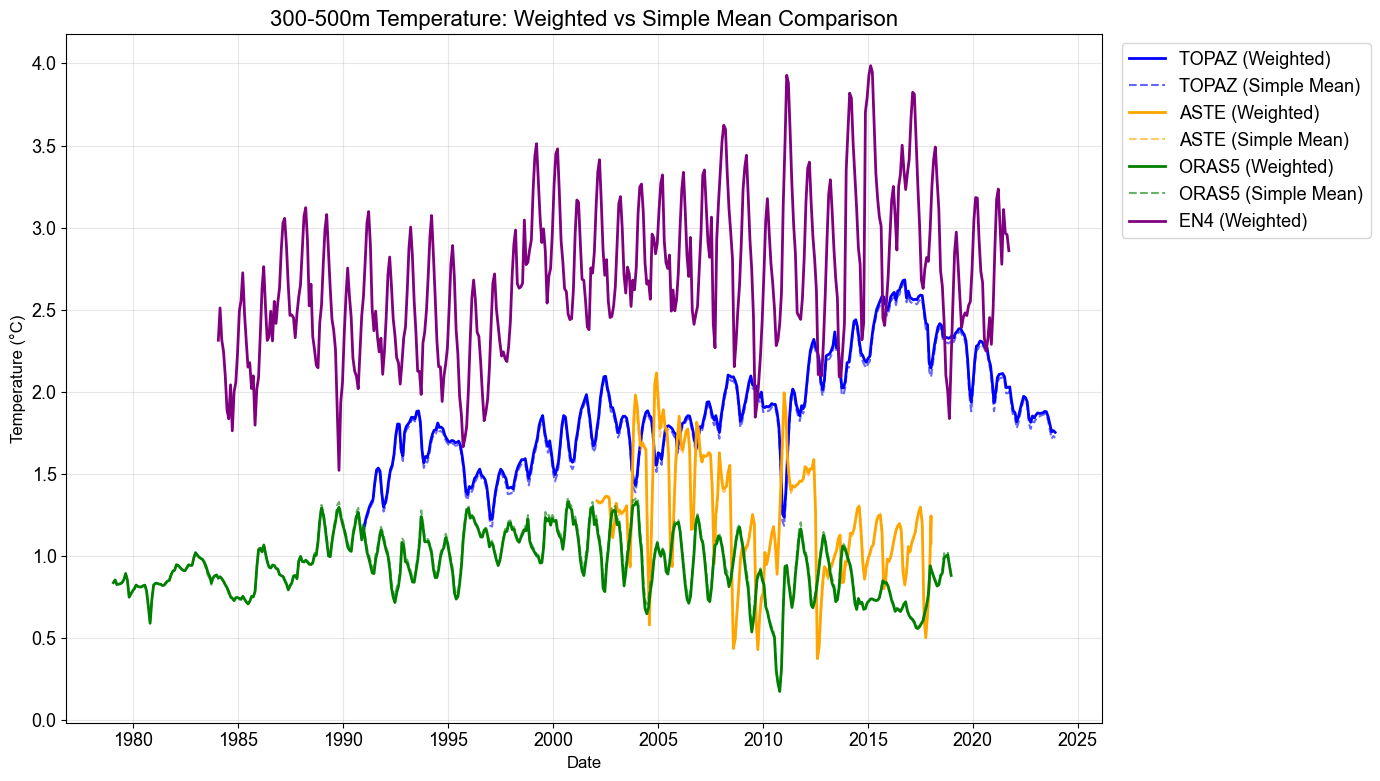

In [57]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def layer_weighted_mean(ds, var_name, depth_dim, min_depth, max_depth, depth_coord=None):
    """
    Calculates the depth-weighted mean of a variable between min_depth and max_depth.
    """
    if depth_coord is None:
        depth_coord = depth_dim
        
    # Extract depths and ensure they are positive for calculation
    depths = ds[depth_coord].values
    abs_depths = np.abs(depths)
    
    # Sort depths (important for correct integration if data isn't monotonic)
    da = ds[var_name]
    order = np.argsort(abs_depths)
    abs_depths = abs_depths[order]
    
    # Reorder the DataArray to match sorted depths
    da = da.isel({depth_dim: order})
    
    # --- 1. Calculate Layer Thicknesses (drF) from centers ---
    # Bounds_i = (Center_i + Center_{i+1}) / 2
    bounds = np.zeros(len(abs_depths) + 1)
    midpoints = 0.5 * (abs_depths[:-1] + abs_depths[1:])
    bounds[1:-1] = midpoints
    # Extrapolate outer bounds
    bounds[0] = abs_depths[0] - (bounds[1] - abs_depths[0])
    bounds[-1] = abs_depths[-1] + (abs_depths[-1] - bounds[-2])
    
    if bounds[0] < 0: bounds[0] = 0
    
    # --- 2. Calculate Weights (Intersection with 300-500m) ---
    layer_tops = bounds[:-1]
    layer_bots = bounds[1:]
    
    # Calculate overlap between [layer_top, layer_bot] and [min_depth, max_depth]
    weights_arr = np.maximum(0, np.minimum(layer_bots, max_depth) - np.maximum(layer_tops, min_depth))
    weights = xr.DataArray(weights_arr, coords={depth_dim: da[depth_dim]}, dims=depth_dim)
    
    # --- 3. Compute Weighted Mean ---
    weighted_sum = (da * weights).sum(dim=depth_dim)
    total_weights = weights.where(da.notnull()).sum(dim=depth_dim)
    
    return weighted_sum / total_weights

# ---------------------------------------------------------
# 1. TOPAZ Arctic Ocean Reanalysis
# ---------------------------------------------------------
print("--- Loading TOPAZ ---")
def load_topaz():
    ds = xr.open_dataset(cfg['paths']['topaz4_store_file'])
    
    # Weighted
    weighted = layer_weighted_mean(ds, 'thetao', 'depth', 300, 500)
    # Unweighted
    unweighted = ds['thetao'].sel(depth=slice(300, 500)).mean(dim='depth')
    
    df = pd.DataFrame({
        'TOPAZ_weighted': weighted.to_series(),
        'TOPAZ_unweighted': unweighted.to_series()
    }).reset_index().set_index('time').resample('MS').mean()
    return df

topaz_df = load_topaz()

# ---------------------------------------------------------
# 2. ASTE Regional Arctic Model
# ---------------------------------------------------------
print("--- Loading ASTE ---")
aste_ds = xr.open_dataset('../data/reanalysis/ASTE_theta_timeseries_optimized.nc')

# Weighted
aste_weighted = layer_weighted_mean(aste_ds, 'THETA', 'k', 300, 500, depth_coord='Depth_m')
# Unweighted (Filter for negative depths between -200 and -500)
aste_unweighted = aste_ds['THETA'].where((aste_ds.Depth_m <= -300) & (aste_ds.Depth_m >= -500), drop=True).mean(dim='k')

aste_df = pd.DataFrame({
    'time': aste_ds.time,
    'ASTE_weighted': aste_weighted.values,
    'ASTE_unweighted': aste_unweighted.values
})
aste_df['datetime'] = pd.to_datetime(aste_df['time'])
aste_df = aste_df.set_index('datetime').drop(columns=['time'])

# ---------------------------------------------------------
# 3. ORAS5 Global Reanalysis
# ---------------------------------------------------------
print("--- Loading ORAS5 ---")
def decimal_year_to_datetime(decimal_year):
    year = int(decimal_year)
    year_start = pd.Timestamp(year=year, month=1, day=1)
    year_fraction = decimal_year - year
    return year_start + pd.Timedelta(days=year_fraction * 365.25)

oras5_ds = xr.open_dataset(cfg['paths']['oras5_store_file'])

# Weighted
oras5_weighted = layer_weighted_mean(oras5_ds, 'temperature', 'depth', 300, 500)
# Unweighted
oras5_unweighted = oras5_ds['temperature'].sel(depth=slice(300, 500)).mean(dim='depth')

oras5_df = pd.DataFrame({
    'time': oras5_ds['decimal_year'],
    'ORAS5_weighted': oras5_weighted.values,
    'ORAS5_unweighted': oras5_unweighted.values
})
oras5_df['datetime'] = oras5_df['time'].apply(decimal_year_to_datetime)
oras5_df = oras5_df.set_index('datetime').drop(columns=['time'])

# ---------------------------------------------------------
# 4. EN4 Global Reanalysis
# ---------------------------------------------------------
print("--- Loading EN4 ---")
EN4_ds = xr.open_dataset('../data/reanalysis/EN4_temp_300-500m_71N_54W.nc')
# EN4 already has depth-weighted average temperature between 300-500m
EN4_temp = EN4_ds['temperature']
EN4_df = EN4_temp.to_dataframe(name='temperature').reset_index()
EN4_df['datetime'] = pd.to_datetime(EN4_df['time'])
EN4_df = EN4_df.set_index('datetime').drop(columns=['time'])

print(f"EN4 data loaded: {len(EN4_df)} records")
print(f"Date range: {EN4_df.index.min()} to {EN4_df.index.max()}")

# ---------------------------------------------------------
# Plotting Comparison (All Models)
# ---------------------------------------------------------
plt.figure(figsize=(14, 8))

# Define styles (excluding ECCO as per user request)
models = [
    (topaz_df, 'TOPAZ', 'blue'),
    (aste_df, 'ASTE', 'orange'),
    (oras5_df, 'ORAS5', 'green'),
    (EN4_df, 'EN4', 'purple')
]

for df, name, color in models:
    if name == 'EN4':
        # EN4 only has weighted temperature (already averaged)
        plt.plot(df.index, df['temperature'], 
                 label=f'{name} (Weighted)', color=color, linewidth=2)
    else:
        plt.plot(df.index, df[f'{name}_weighted'], 
                 label=f'{name} (Weighted)', color=color, linewidth=2)
        # Plot Unweighted (Dashed)
        plt.plot(df.index, df[f'{name}_unweighted'], 
                 label=f'{name} (Simple Mean)', color=color, linestyle='--', alpha=0.6)

plt.title('300-500m Temperature: Weighted vs Simple Mean Comparison', fontsize=16)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left') # Legend outside plot
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Coordinates successfully extracted:
  TOPAZ: 71.0000 N, -54.0000 W
  ASTE: 70.9200 N, -55.1400 W
  ORAS5: 70.8900 N, -53.7269 W
  EN4: 71.0000 N, -54.0000 W


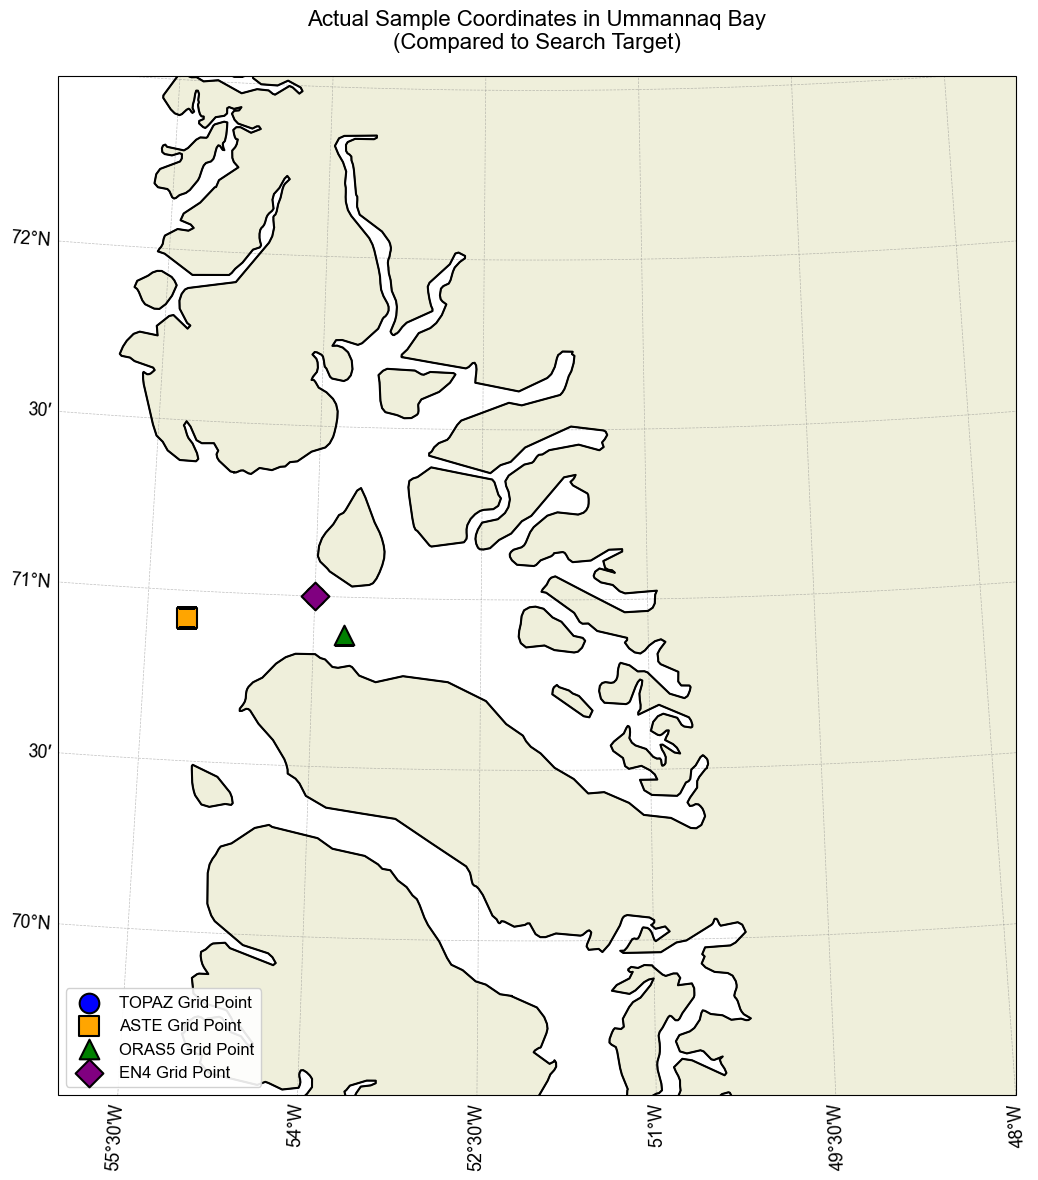

In [58]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import geopandas as gpd

# Gather coordinates into a dictionary
model_coords = {}
# TOPAZ
model_coords['TOPAZ'] = (71.0000, -54.0000)
# ASTE
model_coords['ASTE'] = (70.92, -55.14)
# ORAS5
model_coords['ORAS5'] = (70.8900, -53.7269)
# EN4
model_coords['EN4'] = (71.0000, -54.0000)

print("Coordinates successfully extracted:")
for m, (l, lo) in model_coords.items():
    print(f"  {m}: {l:.4f} N, {lo:.4f} W")


# ==========================================
# 2. Create the Cartopy Map
# ==========================================
plt.figure(figsize=(12, 12), dpi=100)

# 2a. Define Projection
# North Polar Stereographic is good for Greenland. 
# We center the projection near our region of interest for minimal distortion.
central_lon = -52
central_lat = 71
projection = ccrs.NorthPolarStereo(central_longitude=central_lon, true_scale_latitude=central_lat)

ax = plt.axes(projection=projection)

# 2b. Define Extent [West, East, South, North]
# Zoom in on Ummannaq Bay region
extent = [-56, -48, 69.5, 72.5]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# 2c. Add Map Features (High Resolution for zoomed map)
resol = '10m' # Requires cartopy data download on first run
land_feature = cfeature.NaturalEarthFeature('physical', 'land', scale=resol,
                                            edgecolor='black', facecolor=cfeature.COLORS['land'])


ax.add_feature(land_feature, zorder=1)
ax.coastlines(resolution=resol, linewidth=1.5, zorder=3)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False # Turn off top labels for cleaner look
gl.right_labels = False

# 2d. Plot the Model Points
# Define styles to match the previous time series plot
styles = {
    'TOPAZ': {'color': 'blue', 'marker': 'o'},
    'ASTE':  {'color': 'orange', 'marker': 's'}, # square
    'ORAS5': {'color': 'green', 'marker': '^'},  # triangle up
    'EN4': {'color': 'purple', 'marker': 'D'},    # diamond
}

# Plot model grid points
for model_name, (lat, lon) in model_coords.items():
    style = styles[model_name]
    # Note: transform=ccrs.PlateCarree() tells cartopy that our lat/lon are plain coordinates
    ax.scatter(lon, lat, color=style['color'], marker=style['marker'], s=200,
               edgecolor='black', linewidth=1.5,
               transform=ccrs.PlateCarree(), 
               label=f'{model_name} Grid Point', zorder=10)
    
    # Optional: Add label directly on map next to point
    # ax.text(lon + 0.05, lat + 0.02, model_name, transform=ccrs.PlateCarree(),
    #         fontsize=10, fontweight='bold', color=style['color'], zorder=11)


# 2e. Titles and Legend
plt.title('Actual Sample Coordinates in Ummannaq Bay\n(Compared to Search Target)', fontsize=16, pad=20)
legend = ax.legend(loc='lower left', frameon=True, framealpha=0.9, fontsize=12)
legend.set_zorder(20) # Ensure legend is on top

plt.tight_layout()
plt.show()

# export coordinates to a shp file
gdf = gpd.GeoDataFrame(
    [{'model': model_name, 'geometry': gpd.points_from_xy([lon], [lat])[0]} 
     for model_name, (lat, lon) in model_coords.items()],
    crs="EPSG:4326"  # WGS84 Latitude/Longitude
)
# save to data/shapefiles
shapefiles_dir = "../data/shapefiles"
gdf.to_file(f"{shapefiles_dir}/ model_coordinates.shp")

## 2. Load Landsat Plume Data

In [59]:
# Load Landsat plume SST data
csv_directory = cfg['paths']['landsat_plume_sst_dir']
csv_files = glob.glob(f"{csv_directory}/*.csv")
print(f"Found {len(csv_files)} CSV files")

df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)
print(f"Total rows: {len(df)}")

# Extract sensor information
def get_landsat_sensor(row):
    """Extract Landsat sensor from available columns"""
    # Check for direct sensor column
    if 'satellite' in row.index and pd.notna(row['satellite']):
        return row['satellite']
    elif 'SPACECRAFT_ID' in row.index and pd.notna(row['SPACECRAFT_ID']):
        return row['SPACECRAFT_ID']
    elif 'system:index' in row.index and pd.notna(row['system:index']):
        # Extract from Landsat image ID (e.g., LC08_123456_20200101)
        img_id = str(row['system:index'])
        if 'LT04' in img_id or 'LT4' in img_id:
            return 'Landsat 4'
        elif 'LT05' in img_id or 'LT5' in img_id:
            return 'Landsat 5'
        elif 'LE07' in img_id or 'LE7' in img_id:
            return 'Landsat 7'
        elif 'LC08' in img_id or 'LC8' in img_id:
            return 'Landsat 8'
        elif 'LC09' in img_id or 'LC9' in img_id:
            return 'Landsat 9'
    # Try to infer from date if no sensor info available
    if 'date' in row.index:
        year = pd.to_datetime(row['date']).year
        if year < 1984:
            return 'Landsat 4'
        elif year < 1999:
            return 'Landsat 5'
        elif year < 2013:
            return 'Landsat 7'
        elif year < 2022:
            return 'Landsat 8'
        else:
            return 'Landsat 9'
    return 'Unknown'

df['landsat_sensor'] = df.apply(get_landsat_sensor, axis=1)
df['date'] = pd.to_datetime(df['date'])

df.head()

Found 99 CSV files
Total rows: 111


,system:index,SST_mean,SST_median,SST_stdDev,date,glacier,orig_thermal_band,sensor,sst_masked_mean,sst_masked_median,...,.geo,bt_mean_K,bt_median_K,bt_stddev_K,pixel_count,tqv_kg_m2,bt_mad_K,sst_mad_C,water_mask_applied,landsat_sensor
0,0,1.981638,2.188429,0.259220,1985-06-15,NEW_REVISIONS_STORE_north_v4,B6,LANDSAT_5,1.981638,2.188429,...,"{""type"":""Polygon"",""coordinates"":[[[-50.5756096...",273.256091,273.456604,0.252717,53,5.085844,0.0,0.0,NaN,Landsat 5
1,0,1.889018,1.641492,0.253708,1985-06-22,NEW_REVISIONS_STORE_north_v4,B6,LANDSAT_5,1.889018,1.641492,...,"{""type"":""Polygon"",""coordinates"":[[[-50.5824686...",273.163462,272.922974,0.247344,16,7.120080,0.0,0.0,NaN,Landsat 5
2,0,1.543979,1.641545,0.214766,1985-07-01,NEW_REVISIONS_STORE_north_v4,B6,LANDSAT_5,1.543979,1.641545,...,"{""type"":""Polygon"",""coordinates"":[[[-50.5787779...",272.828178,272.922974,0.209378,32,7.151731,0.0,0.0,NaN,Landsat 5
3,0,1.727053,1.642116,0.280729,1985-07-03,NEW_REVISIONS_STORE_north_v4,B6,LANDSAT_5,1.727053,1.642116,...,"{""type"":""Polygon"",""coordinates"":[[[-50.5803229...",273.005526,272.922974,0.273687,99,7.493137,0.0,0.0,NaN,Landsat 5
4,0,0.324686,0.527551,0.268307,1985-08-18,NEW_REVISIONS_STORE_north_v4,B6,LANDSAT_5,0.324686,0.527551,...,"{""type"":""Polygon"",""coordinates"":[[[-50.6215511...",271.650536,271.847168,0.261577,19,4.704036,0.0,0.0,NaN,Landsat 5


## 3. Map Plume Temperatures to Grounding Line

In [60]:

def extract_polygon_centroid(geo_string):
    """Extract centroid lon, lat from GeoJSON Polygon geometry"""
    try:
        geo_data = json.loads(geo_string)
        geom_type = geo_data['type']
        
        if geom_type == 'Polygon':
            # Create a shapely polygon from coordinates
            from shapely.geometry import Polygon
            coords = geo_data['coordinates'][0]  # First ring is exterior
            polygon = Polygon(coords)
            centroid = polygon.centroid
            return pd.Series({'lon_centroid': centroid.x, 'lat_centroid': centroid.y})
        elif geom_type == 'Point':
            # Handle legacy point data if any
            coords = geo_data['coordinates']
            return pd.Series({'lon_centroid': coords[0], 'lat_centroid': coords[1]})
        else:
            return pd.Series({'lon_centroid': np.nan, 'lat_centroid': np.nan})
    except Exception as e:
        return pd.Series({'lon_centroid': np.nan, 'lat_centroid': np.nan})

# Extract centroid coordinates from .geo column
print("Extracting polygon centroids...")
centroids = df['.geo'].apply(extract_polygon_centroid)
df['lon_centroid'] = centroids['lon_centroid']
df['lat_centroid'] = centroids['lat_centroid']

df['longitude'] = df['lon_centroid']
df['latitude'] = df['lat_centroid']

# Remove rows with missing coordinates
df = df.dropna(subset=['lon_centroid', 'lat_centroid'])

# Load grounding line depth data from Ryan et al. 2015
gl_data = pd.read_csv(cfg['paths']['store_bathymetry_csv'])
gl_data = gl_data.sort_values(by='distance')
gl_data['distance'] = gl_data['distance'] * 1000  # convert km to m

print("Grounding line data loaded:")
print(f"\nDepth range: {gl_data['depth'].min():.1f} to {gl_data['depth'].max():.1f} m")

# Load ice front shapefile
shapefile_icefront = gpd.read_file(cfg['paths']['store_icefront_shp'])   
shapefile_icefront.crs = 'EPSG:4326'  

# Convert to UTM for distance calculations
shapefile_icefront = shapefile_icefront.to_crs(epsg=3413)
line = shapefile_icefront.geometry.iloc[0]

# Calculate cumulative distance along ice front
icefront_data = pd.DataFrame([(x, y) for x, y in line.coords], columns=['x', 'y'])
icefront_data['dx'] = icefront_data['x'].diff()
icefront_data['dy'] = icefront_data['y'].diff()
icefront_data['segment_length'] = np.sqrt(icefront_data['dx']**2 + icefront_data['dy']**2)
icefront_data['distance'] = icefront_data['segment_length'].cumsum().fillna(0)

print("Ice front shapefile loaded and processed")
print(f"Ice front length: {icefront_data['distance'].max()/1000:.2f} km")

# Define functions to map coordinates to grounding line depth

def find_nearest_depth(icefront_dist, gl_distances, gl_depths):
    """Returns depth from nearest grounding line point"""
    idx = np.abs(gl_distances - icefront_dist).argmin()
    return gl_depths.iloc[idx]

def get_nearest_depth(lat, lon, shapefile, gl_data):
    """
    Finds the nearest point on a shapefile line to given coordinates
    and returns the associated grounding line depth.
    
    Args:
        lat, lon (float): Input coordinates (WGS84)
        shapefile (GeoDataFrame): Line geometry of icefront
        gl_data (DataFrame): Grounding line data with 'distance' and 'depth'
        
    Returns:
        float: Depth at nearest point (meters)
    """
    # Convert input to GeoSeries in WGS84
    point = gpd.GeoSeries(
        gpd.points_from_xy([lon], [lat]), 
        crs="EPSG:4326"
    )
    
    # Reproject to same CRS as shapefile (UTM 3413)
    point_utm = point.to_crs(shapefile.crs)
    line = shapefile.geometry.iloc[0]
    
    # Find nearest point on line
    nearest_point_on_line = line.interpolate(line.project(point_utm.iloc[0]))
    
    # Calculate distance along line to this point
    distance_along_line = line.project(nearest_point_on_line)
    
    # Find closest grounding line point by distance
    gl_idx = np.abs(gl_data['distance'] - distance_along_line).argmin()
    
    return gl_data.iloc[gl_idx]['depth']

def batch_nearest_depths(coords, shapefile, gl_data):
    """Process multiple coordinates at once"""
    return [get_nearest_depth(lat, lon, shapefile, gl_data) 
            for lat, lon in coords]

def get_line_distance(lat, lon, shapefile):
    """Calculate distance along line for given coordinates"""
    point = gpd.GeoSeries(
        gpd.points_from_xy([lon], [lat]),
        crs="EPSG:4326"
    ).to_crs(shapefile.crs)
    line = shapefile.geometry.iloc[0]
    return line.project(line.interpolate(line.project(point.iloc[0])))

print("Grounding line mapping functions defined")

# Calculate grounding line depth and distance for each point
print("Mapping plume locations to grounding line depths...")

# Prepare coordinates
coords_list = list(zip(df['latitude'], df['longitude']))

# Calculate depths and distances
df['gl_depth'] = batch_nearest_depths(coords_list, shapefile_icefront, gl_data)
df['distance_along_icefront'] = [get_line_distance(lat, lon, shapefile_icefront) 
                                   for lat, lon in coords_list]

print(f"\nGrounding line depth mapped for {len(df)} points")

Extracting polygon centroids...
Grounding line data loaded:

Depth range: -542.5 to -123.8 m
Ice front shapefile loaded and processed
Ice front length: 5.30 km
Grounding line mapping functions defined
Mapping plume locations to grounding line depths...

Grounding line depth mapped for 111 points


# 4. Plot spatial distrubution/ density

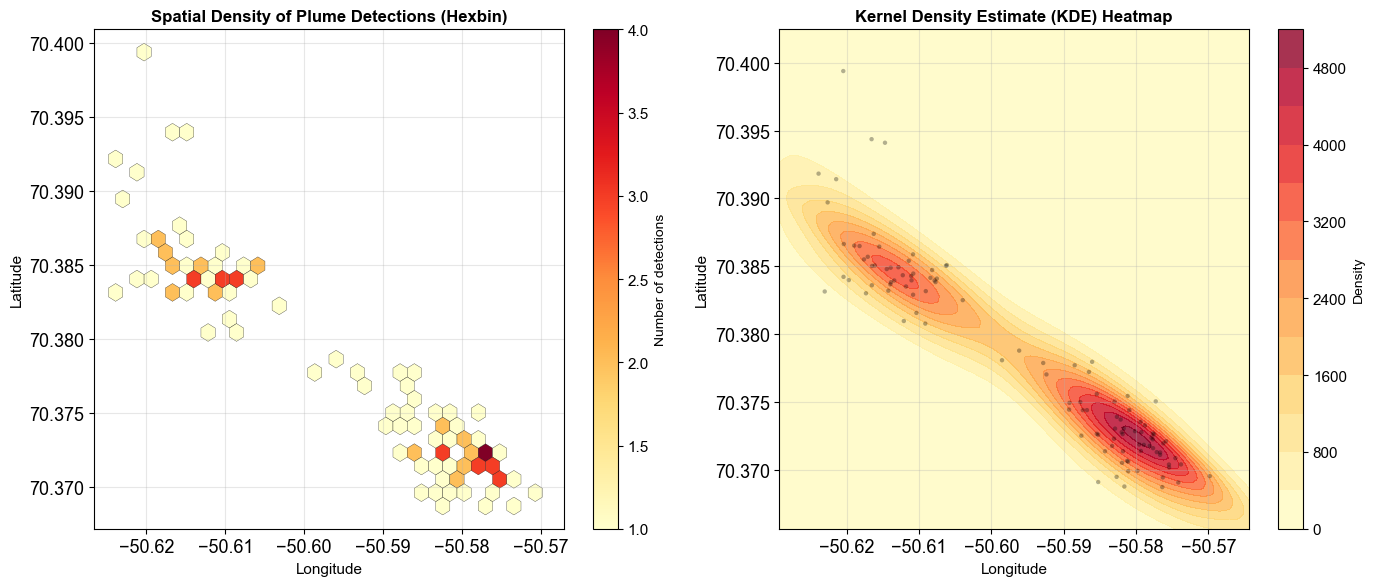


Spatial distribution statistics:
Total plume detections: 111
Longitude spread: 0.0168°
Latitude spread: 0.0070°


In [61]:
# Create spatial heatmap of plume detections
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11

# 1. Hexbin plot showing density
ax1 = axes[0]
hexbin = ax1.hexbin(df['lon_centroid'], df['lat_centroid'], 
                     gridsize=30, cmap='YlOrRd', mincnt=1, edgecolors='black', linewidths=0.2)
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.set_title('Spatial Density of Plume Detections (Hexbin)', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(hexbin, ax=ax1)
cbar1.set_label('Number of detections', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. KDE contour plot
ax2 = axes[1]

# Calculate kernel density estimate
lon = df['lon_centroid'].values
lat = df['lat_centroid'].values
xy = np.vstack([lon, lat])
kde = gaussian_kde(xy)

# Create grid for KDE evaluation
lon_min, lon_max = lon.min(), lon.max()
lat_min, lat_max = lat.min(), lat.max()
lon_range = lon_max - lon_min
lat_range = lat_max - lat_min
lon_grid = np.linspace(lon_min - 0.1*lon_range, lon_max + 0.1*lon_range, 100)
lat_grid = np.linspace(lat_min - 0.1*lat_range, lat_max + 0.1*lat_range, 100)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
positions = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])
density = kde(positions).reshape(lon_mesh.shape)

# Plot filled contours
contour = ax2.contourf(lon_mesh, lat_mesh, density, levels=15, cmap='YlOrRd', alpha=0.8)
ax2.scatter(lon, lat, c='black', s=10, alpha=0.3, edgecolors='none')
ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
ax2.set_title('Kernel Density Estimate (KDE) Heatmap', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(contour, ax=ax2)
cbar2.set_label('Density', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSpatial distribution statistics:")
print(f"Total plume detections: {len(df)}")
print(f"Longitude spread: {df['lon_centroid'].std():.4f}°")
print(f"Latitude spread: {df['lat_centroid'].std():.4f}°")

Filtering plumes with origin depth < -380 m (deeper than 380m)
Points before filtering: 111
Points after filtering: 98
Points removed: 13

Remaining depth range: -542.5 to -400.7 m


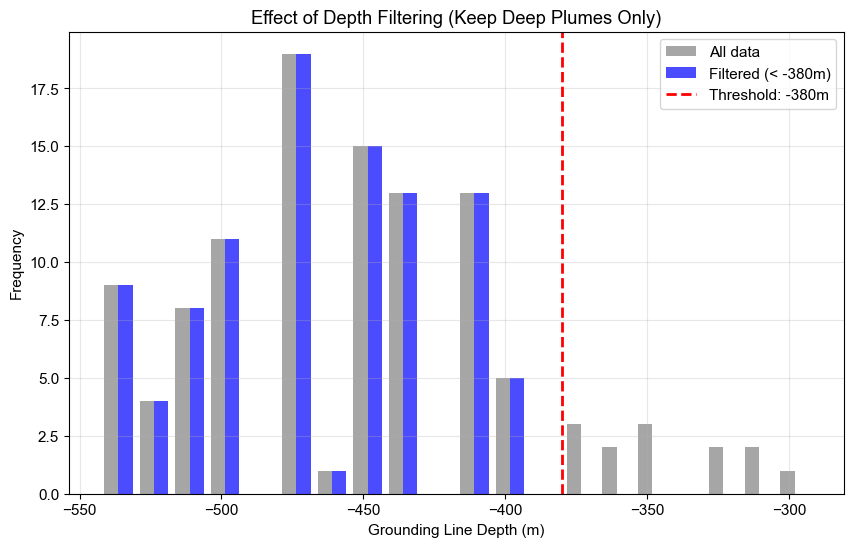

In [62]:
# Filter data by grounding line depth
# Keep only plumes originating from deep grounding line (> 380m depth)
depth_threshold = -380  # meters

df_before_filter = df.copy()
df = df[df['gl_depth'] < depth_threshold].copy()

print(f"Filtering plumes with origin depth < {depth_threshold} m (deeper than {abs(depth_threshold)}m)")
print(f"Points before filtering: {len(df_before_filter)}")
print(f"Points after filtering: {len(df)}")
print(f"Points removed: {len(df_before_filter) - len(df)}")
print(f"\nRemaining depth range: {df['gl_depth'].min():.1f} to {df['gl_depth'].max():.1f} m")

# Optional: Visualize the filtered data
plt.figure(figsize=(10, 6))
plt.hist([df_before_filter['gl_depth'], df['gl_depth']], 
         bins=20, label=['All data', f'Filtered (< {depth_threshold}m)'],
         alpha=0.7, color=['gray', 'blue'])
plt.axvline(depth_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {depth_threshold}m')
plt.xlabel('Grounding Line Depth (m)')
plt.ylabel('Frequency')
plt.title('Effect of Depth Filtering (Keep Deep Plumes Only)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\1040412986.py:41: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_main.plot(gl_data['distance'], gl_data['depth'],
C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\1040412986.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_main.set_xticklabels([f'{x:.0f}' for x in xticks_km])
C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\1040412986.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent title overlap


Max value: 20, Half value: 10
Loaded CTD (Ta median): 2020-08-25, depth -524.8 to -0.0 m, 1000 points


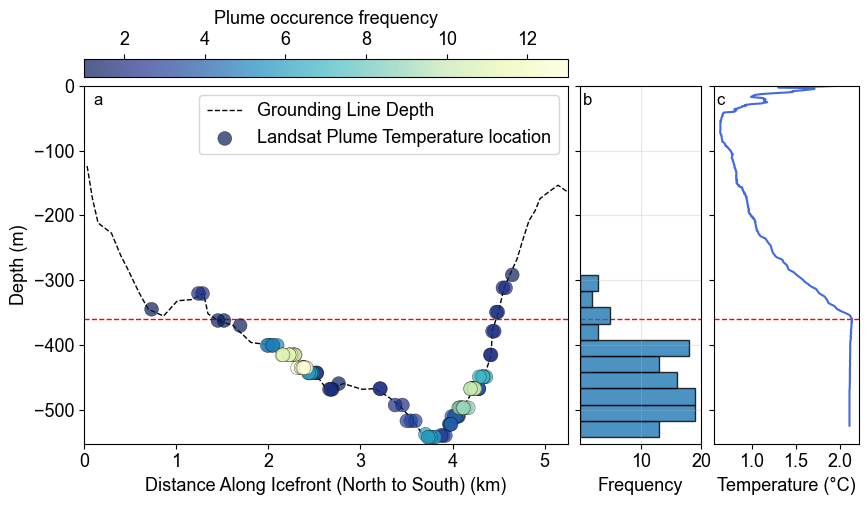

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 13
fig = plt.figure(figsize=(10, 5))

gs = fig.add_gridspec(2, 3, width_ratios=[4, 1, 1.2],
                      height_ratios=[0.05, 1],  # Space for colorbar
                      hspace=0.05, wspace=0.05)

# Create axes
cbar_ax = fig.add_subplot(gs[0, 0])  # Colorbar on top of first column
ax_main = fig.add_subplot(gs[1, 0])  # Main plot
ax_hist = fig.add_subplot(gs[1, 1])  # Histogram
ax_ctd = fig.add_subplot(gs[1, 2])   # CTD plot

# 2. Main plot (grounding line with scatter)
# Extract distances and depths from the dataframe
distances = df_before_filter['distance_along_icefront'].values
depths = df_before_filter['gl_depth'].values

# Define the number of bins for the 2D histogram. You can adjust this value.
n_bins = 20

# Create a 2D histogram to count points in a grid
H, xedges, yedges = np.histogram2d(distances, depths, bins=n_bins)

# For each data point, find which bin it falls into
x_indices = np.digitize(distances, xedges)
y_indices = np.digitize(depths, yedges)

x_indices = np.clip(x_indices, 1, H.shape[0]) - 1
y_indices = np.clip(y_indices, 1, H.shape[1]) - 1

point_frequencies = H[x_indices, y_indices]
idx = point_frequencies.argsort()

# Plot elements
ax_main.plot(gl_data['distance'], gl_data['depth'],
             'k-', linewidth=1, linestyle='--',
             label='Grounding Line Depth', zorder=1)

sc = ax_main.scatter(
    np.array(distances)[idx],
    np.array(depths)[idx],
    c=point_frequencies[idx], # Color by the calculated point frequency
    s=100,
    cmap='YlGnBu_r',
    alpha=0.7,
    edgecolors='k',
    linewidths=0.3,
    label='Landsat Plume Temperature location',
    zorder=2
)

# Formatting
ax_main.set_xlabel('Distance Along Icefront (North to South) (km)')
ax_main.set_ylabel('Depth (m)')
ax_main.set_xlim(0, gl_data['distance'].max())
ax_main.set_ylim(min(gl_data['depth'])-10, 0)
ax_main.legend(loc='upper right')
ax_main.text(0.02, 0.98, 'a', transform=ax_main.transAxes,
             fontsize=12, va='top', ha='left')

# convert xtick labels to km
xticks = ax_main.get_xticks()
xticks_km = xticks / 1000
ax_main.set_xticklabels([f'{x:.0f}' for x in xticks_km])


# 3. Colorbar (on top of main plot)
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal',
                    pad=0.01, aspect=30, shrink=0.5, format='%.0f')

cbar.set_label('Plume occurence frequency', labelpad=5)
cbar_ax.xaxis.set_label_position('top')
cbar_ax.xaxis.set_ticks_position('top')

# Histogram subplot
ax_hist.hist(depths, bins=10, orientation='horizontal',
             density=False, color='#1f78b4',
             alpha=0.8, ec='black')
ax_hist.set_xlabel('Frequency')
ax_hist.yaxis.set_tick_params(labelleft=False)
ax_hist.grid(True, alpha=0.3)
ax_hist.set_ylim(ax_main.get_ylim())  # Match y-limits with main plot

    # max_val = int(round(ax_histy.get_xlim()[1], 1))
    # half_val = int(round(0.5 * ax_histy.get_xlim()[1], 1))
    # ax_histy.set_xticks([half_val, max_val])
    # ax_histy.set_xticklabels([half_val, max_val])

max_val = int(round(ax_hist.get_xlim()[1], 1))
half_val = int(round(0.5 * ax_hist.get_xlim()[1], 1))
print(f'Max value: {max_val}, Half value: {half_val}')
ax_hist.set_xlim(0, max_val)   
ax_hist.set_xticks([half_val, max_val])
ax_hist.set_xticklabels([half_val, max_val])

ax_hist.text(0.02, 0.98, 'b', transform=ax_hist.transAxes,
             fontsize=12, va='top', ha='left')

# 5. CTD subplot - 2020-08-25 ambient CTD profile (Ta) from plume ensemble
ens_ds = xr.open_dataset(REPO_ROOT / 'data/ctd_plume_simulations/STORE_CTD_plume_ensembles.nc')
match_idx = 2  # 2020-08-25 (matches STORE_CTD_landsat_matches_cache.csv row order)
Ta_med = ens_ds['Ta'].isel(match=match_idx).median(dim='ensemble_run')[::-1]
z_med  = ens_ds['z'].isel(match=match_idx).median(dim='ensemble_run')[::-1]
valid = ~(np.isnan(z_med.values) | np.isnan(Ta_med.values))
CTD_depth = z_med.values[valid]  # already negative (0=surface, negative=deeper)
CTD_temp  = Ta_med.values[valid]
print(f"Loaded CTD (Ta median): 2020-08-25, depth {CTD_depth.min():.1f} to {CTD_depth.max():.1f} m, {valid.sum()} points")

ax_ctd.plot(CTD_temp, CTD_depth, color='royalblue',
            linewidth=1.5, label='Temperature')
ax_ctd.set_xlabel('Temperature (°C)')
ax_ctd.set_ylim(ax_main.get_ylim())  # Match y-limits with main plot
ax_ctd.yaxis.set_tick_params(labelleft=False)
ax_ctd.text(0.02, 0.98, 'c', transform=ax_ctd.transAxes,
             fontsize=12, va='top', ha='left')
ax_ctd.set_xticks(np.arange(1, 2.5, 0.5))

for ax in [ax_main, ax_hist, ax_ctd]:
    ax.axhline(-360, color='red', linestyle='--', linewidth=1, zorder=0)
# savefigure
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent title overlap
# Create figures directory if it doesn't exist
# os.makedirs('%s/figures' % (script_dir), exist_ok=True)
# plt.savefig(r'%s/figures/STORE_plume_frequency_plot_south.png' % (script_dir), dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


## 4. Prepare Time Series Data

In [64]:
# Aggregate plume observations to daily medians
df['date'] = pd.to_datetime(df['date'].values)
timeseries_clean = df.dropna(subset=['SST_median']).copy()

print(f"\nTime series prepared:")
print(f"Total observations: {len(timeseries_clean)}")
print(f"Date range: {timeseries_clean['date'].min()} to {timeseries_clean['date'].max()}")
print(f"Temperature range: {timeseries_clean['SST_median'].min():.2f}°C to {timeseries_clean['SST_median'].max():.2f}°C")


Time series prepared:
Total observations: 92
Date range: 1985-06-22 00:00:00 to 2024-08-06 00:00:00
Temperature range: -0.02°C to 3.48°C


## 5. Main Time Series Plot with GPR Trends and Bootstrap CIs

In [65]:
# GPR function with bootstrap confidence intervals
def calculate_confidence_envelope_gpr(dates, values, n_bootstrap=200, length_scale=1.5):
    """
    Calculate GPR trend and bootstrap confidence envelope.

    """
    # Convert dates to decimal years since first observation
    dates_numeric = (dates - dates.min()).dt.total_seconds() / (365.25 * 24 * 3600)
    X = dates_numeric.values.reshape(-1, 1)
    y = values.values

    # Dense prediction grid (500 pts) for a smooth rendered curve
    X_pred = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

    # Fix the length scale so the optimizer cannot choose short values on
    # different bootstrap runs â€” that is what causes gap oscillations.
    kernel = (
        C(1.0, (0.1, 10.0))
        * RBF(length_scale=length_scale, length_scale_bounds="fixed")
        + WhiteKernel(noise_level=0.5, noise_level_bounds=(0.01, 2.0))
    )

    # --- Central trend
    gp_full = GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=5, normalize_y=True
    )
    gp_full.fit(X, y)
    mean_trend, _ = gp_full.predict(X_pred, return_std=True)

    # --- CI: bootstrap resampling (uncertainty only
    smoothed_lines = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(len(X), size=len(X), replace=True)
        gp = GaussianProcessRegressor(
            kernel=kernel, n_restarts_optimizer=0, normalize_y=True
        )
        gp.fit(X[idx], y[idx])
        y_pred, _ = gp.predict(X_pred, return_std=True)
        smoothed_lines.append(y_pred)

    smoothed_array = np.array(smoothed_lines)
    lower = np.percentile(smoothed_array, 2.5, axis=0)
    upper = np.percentile(smoothed_array, 97.5, axis=0)

    pred_dates = dates.min() + pd.to_timedelta(X_pred.flatten() * 365.25, unit="D")
    return pred_dates, mean_trend, lower, upper

# Plume stats

In [66]:
# Plume surface temperature statistics (robust summary + trend)
import numpy as np
from scipy import stats

# remove SST_median < -1
timeseries_clean = timeseries_clean[timeseries_clean['SST_median'] >= -1].copy()
vals = timeseries_clean['SST_median'].dropna().values
dates = timeseries_clean['date'].dropna()

# Basic moments
mean_sst = vals.mean()
median_sst = np.median(vals)
std_sst = vals.std(ddof=1)
variance_sst = vals.var(ddof=1)
min_sst = vals.min()
max_sst = vals.max()
range_width = max_sst - min_sst

# Percentiles and IQR
q05, q25, q50, q75, q95 = np.percentile(vals, [5, 25, 50, 75, 95])
iqr = q75 - q25

# Bootstrap 95% CI for median
rng = np.random.default_rng(42)
n_boot = 500
boot_medians = []
for _ in range(n_boot):
    boot_sample = rng.choice(vals, size=len(vals), replace=True)
    boot_medians.append(np.median(boot_sample))
median_ci_lower, median_ci_upper = np.percentile(boot_medians, [2.5, 97.5])

# Linear trend (C per decade) using OLS
decimal_year = dates.dt.year + (dates.dt.dayofyear - 1) / 365.25
slope, intercept, r_value, p_value, stderr = stats.linregress(decimal_year, vals)
trend_per_decade = slope * 10
trend_ci = 1.96 * stderr * 10  # ~95% CI width
r2 = r_value ** 2

print("\nPlume Surface Temperature Statistics:")
print(f"N: {len(vals)}; span: {dates.min().date()} to {dates.max().date()}")
print(f"Mean: {mean_sst:.2f}°C; Median: {median_sst:.2f}°C")
print(f"Std: {std_sst:.2f}°C; Variance: {variance_sst:.3f}°C²")
print(f"Range: {min_sst:.2f} to {max_sst:.2f}°C (width {range_width:.2f}°C)")
print(f"IQR (25–75%): {q25:.2f} to {q75:.2f}°C (width {iqr:.2f}°C)")
print(f"5th/95th percentiles: {q05:.2f} to {q95:.2f}°C")
print(f"Median 95% CI (bootstrap): {median_ci_lower:.2f} to {median_ci_upper:.2f}°C (n_boot={n_boot})")
print(f"Trend: {trend_per_decade:.2f} °C/decade (±{trend_ci:.2f}, p={p_value:.3f}, R²={r2:.2f})")


Plume Surface Temperature Statistics:
N: 92; span: 1985-06-22 to 2024-08-06
Mean: 1.86°C; Median: 1.97°C
Std: 0.74°C; Variance: 0.542°C²
Range: -0.02 to 3.48°C (width 3.50°C)
IQR (25–75%): 1.55 to 2.30°C (width 0.75°C)
5th/95th percentiles: 0.44 to 2.84°C
Median 95% CI (bootstrap): 1.70 to 2.19°C (n_boot=500)
Trend: 0.17 °C/decade (±0.14, p=0.018, R²=0.06)


Calculating GPR trend for Landsat (this may take a minute...)


c:\Users\s1834371\AppData\Local\miniconda3\envs\c3_winterslowdown\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\s1834371\AppData\Local\miniconda3\envs\c3_winterslowdown\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\768290379.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


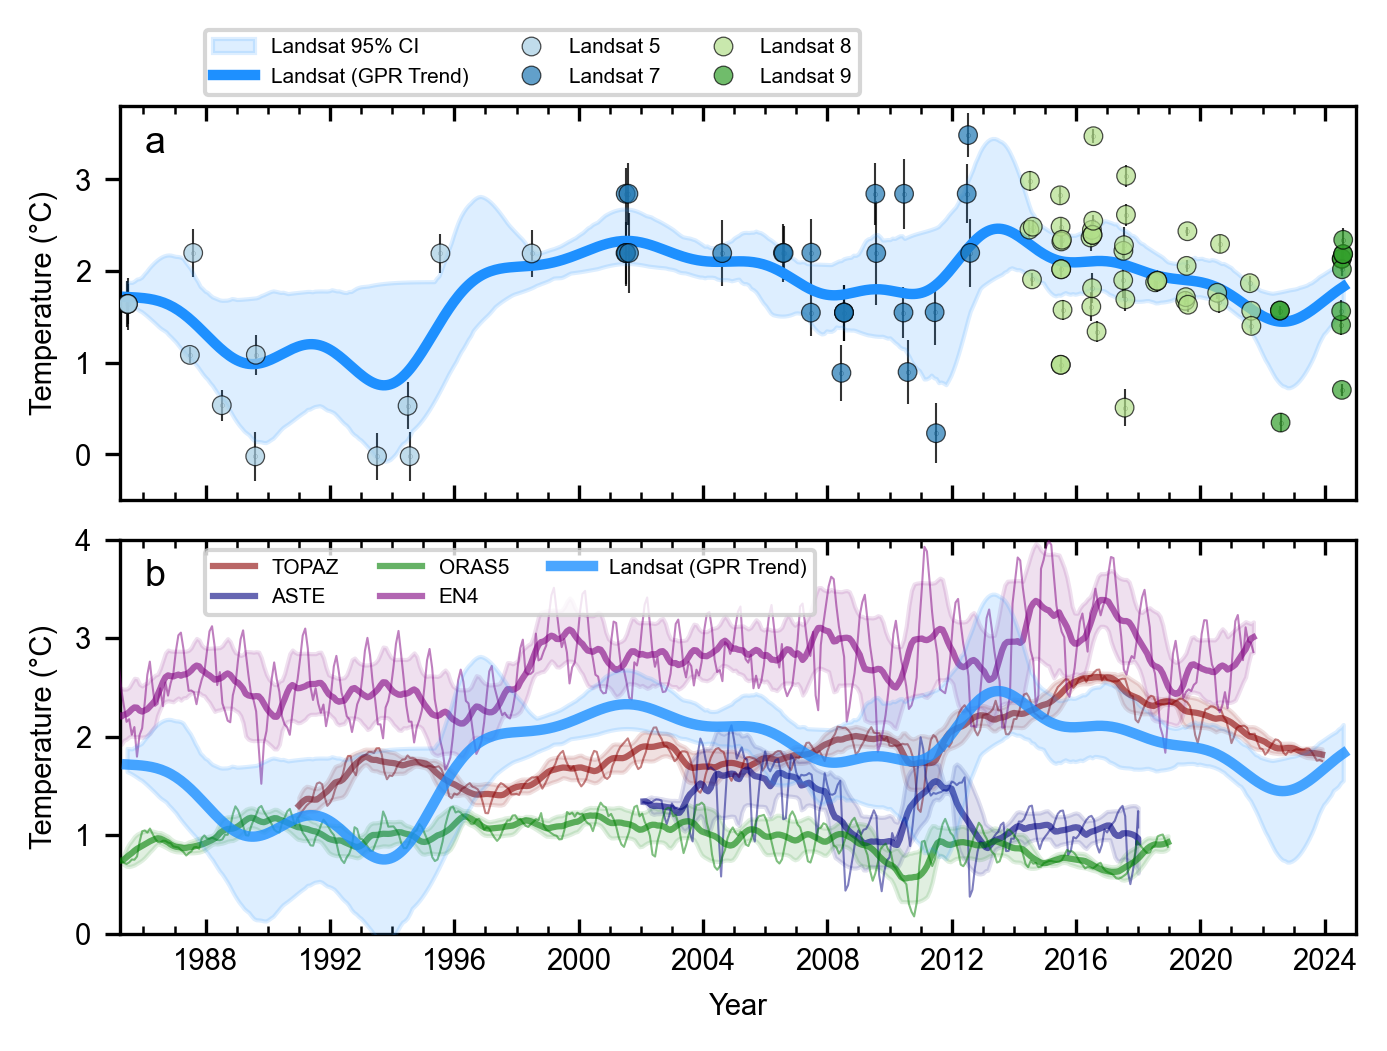

In [67]:
# Create main time series figure

fig_width_mm = 135
# Doubling height for 2 rows to keep aspect ratio of individual plots similar
fig_height_mm = 70 * 1.3
inches_per_mm = 0.0393701

# Changed to 2 rows, sharex=True aligns the dates
fig, axes = plt.subplots(nrows=2, ncols=1, 
                         figsize=(fig_width_mm * inches_per_mm, fig_height_mm * inches_per_mm), 
                         dpi=300, sharex=True, gridspec_kw={'hspace': 0.1})

# Calculate smoothed trends for reanalysis models
topaz_smoothed = topaz_df['TOPAZ_weighted'].rolling(window=14, center=True, min_periods=7).mean()
topaz_std = topaz_df['TOPAZ_weighted'].rolling(window=14, center=True, min_periods=7).std()

aste_smoothed = aste_df['ASTE_weighted'].rolling(window=14, center=True, min_periods=7).mean()
aste_std = aste_df['ASTE_weighted'].rolling(window=14, center=True, min_periods=7).std()

oras5_smoothed = oras5_df['ORAS5_weighted'].rolling(window=14, center=True, min_periods=7).mean()
oras5_std = oras5_df['ORAS5_weighted'].rolling(window=14, center=True, min_periods=7).std()

en4_smoothed = EN4_df['temperature'].rolling(window=14, center=True, min_periods=7).mean()
en4_std = EN4_df['temperature'].rolling(window=14, center=True, min_periods=7).std()

# Calculate GPR trend for Landsat
print("Calculating GPR trend for Landsat (this may take a minute...)")
pred_dates, gpr_trend, lower_ci, upper_ci = calculate_confidence_envelope_gpr(
    timeseries_clean['date'], 
    timeseries_clean['SST_median'], 
    n_bootstrap=200,
    length_scale=1.5
)

# Landsat Observations + GPR (Current View)
ax_top = axes[0]

# Plot Landsat with GPR trend and bootstrap CI
ax_top.fill_between(pred_dates, lower_ci, upper_ci,
                color='dodgerblue', alpha=0.15, 
                label='Landsat 95% CI', zorder=4)

ax_top.plot(pred_dates, gpr_trend,
        color='dodgerblue', linewidth=2.5, 
        label='Landsat (GPR Trend)', zorder=5)

# Plot Landsat observations
sns.scatterplot(data=timeseries_clean, x='date', y='SST_median', 
               hue='landsat_sensor', palette='Paired', s=20, 
               edgecolor='black', linewidth=0.3, ax=ax_top, alpha=0.7, zorder=6)

ax_top.errorbar(timeseries_clean['date'], timeseries_clean['SST_median'],
                yerr=timeseries_clean['SST_stdDev'], fmt='o', color='black', alpha=0.8, markersize=0.1, capsize=0, elinewidth=0.5, zorder=-1)


#  Reanalysis Models + Landsat GPR
ax_bot = axes[1]

# #TOPAZ
ax_bot.plot(topaz_df.index, topaz_df['TOPAZ_weighted'],
        color='darkred', linewidth=0.5, zorder=3, alpha=0.5)
ax_bot.fill_between(topaz_df.index, 
                  topaz_smoothed - topaz_std, topaz_smoothed + topaz_std,
                  color='darkred', alpha=0.12, zorder=2)
ax_bot.plot(topaz_df.index, topaz_smoothed,
         color='darkred', linewidth=1.5, zorder=3, alpha=0.6, label='TOPAZ')

# #ASTE
ax_bot.plot(aste_df.index, aste_df['ASTE_weighted'],
        color='navy', linewidth=0.5, zorder=3, alpha=0.5)
ax_bot.fill_between(aste_df.index, 
                  aste_smoothed - aste_std, aste_smoothed + aste_std,
                  color='navy', alpha=0.12, zorder=2)
ax_bot.plot(aste_df.index, aste_smoothed,
        color='navy', linewidth=1.5, 
        zorder=3, alpha=0.6, label='ASTE')

# #ORAS5
ax_bot.plot(oras5_df.index, oras5_df['ORAS5_weighted'],
        color='green', linewidth=0.5, zorder=3, alpha=0.5)
ax_bot.fill_between(oras5_df.index, 
                  oras5_smoothed - oras5_std, oras5_smoothed + oras5_std,
                  color='green', alpha=0.12, zorder=2)
ax_bot.plot(oras5_df.index, oras5_smoothed,
        color='green', linewidth=1.5, 
        zorder=3, alpha=0.6, label='ORAS5')

# #EN4
ax_bot.plot(EN4_df.index, EN4_df['temperature'],
        color='purple', linewidth=0.5, zorder=3, alpha=0.5)
ax_bot.fill_between(EN4_df.index, 
                  en4_smoothed - en4_std, en4_smoothed + en4_std,
                  color='purple', alpha=0.12, zorder=2)
ax_bot.plot(EN4_df.index, en4_smoothed,
        color='purple', linewidth=1.5, 
        zorder=3, alpha=0.6, label='EN4')

# Landsat GPR (repeated for comparison)
ax_bot.fill_between(pred_dates, lower_ci, upper_ci,
                color='dodgerblue', alpha=0.15, zorder=4) # No label to avoid duplicate in legend if preferred
ax_bot.plot(pred_dates, gpr_trend,
        color='dodgerblue', linewidth=2.5, 
        label='Landsat (GPR Trend)', zorder=5, alpha=0.8)

# FORMATTING 
for ax in axes:
    ax.set_xlim(pd.Timestamp('1985-04-01'), pd.Timestamp('2025-01-01'))

    # Formatting x-axis
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_ticks_position('both')
    ax.xaxis.set_tick_params(which='both', direction='in')

    # General Formatting
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.grid(False)
    ax.set_ylabel('Temperature (°C)', fontsize=7)
    plt.setp(ax.get_xticklabels(), rotation=0)

# Specific tweaks
ax_top.set_xlabel('') # Hide x label for top plot
ax_top.legend(loc='upper left', fontsize=5, ncol=3, bbox_to_anchor=(0.06, 1.22)) # Legend above plot with box
ax_top.set_ylim(-0.5, 3.8)

ax_bot.set_xlabel('Year', fontsize=7)
ax_bot.legend(loc='upper left', fontsize=5, ncol=3, bbox_to_anchor=(0.06, 1)) # ncol=3 fits the 5 items better
ax_bot.set_ylim(0, 4)

# add (a) and (b) labels
ax_top.text(0.02, 0.95, 'a', transform=ax_top.transAxes,
         fontsize=9, va='top', ha='left')
ax_bot.text(0.02, 0.95, 'b', transform=ax_bot.transAxes,
         fontsize=9, va='top', ha='left')

plt.tight_layout()
plt.show()

C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\987766800.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  topaz_yearly = topaz_df['TOPAZ_weighted'].resample('Y').mean()
C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\987766800.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  aste_yearly = aste_df['ASTE_weighted'].resample('Y').mean()
C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\987766800.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  oras5_yearly = oras5_df['ORAS5_weighted'].resample('Y').mean()
C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\987766800.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  en4_yearly = EN4_df['temperature'].resample('Y').mean()


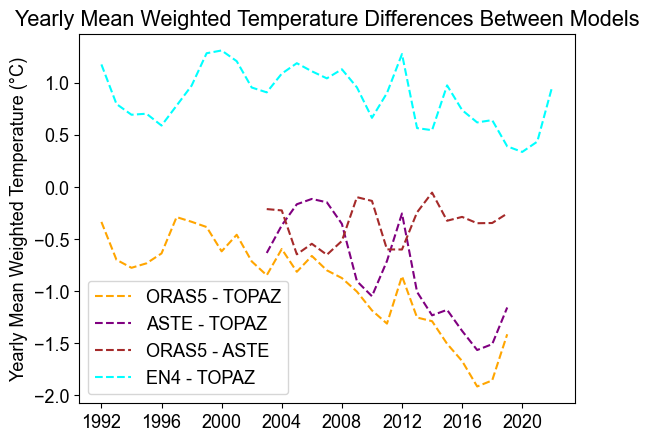

In [68]:
# calculate and plot uyearly mean weughted temperature for each model
topaz_yearly = topaz_df['TOPAZ_weighted'].resample('Y').mean()
aste_yearly = aste_df['ASTE_weighted'].resample('Y').mean() 
oras5_yearly = oras5_df['ORAS5_weighted'].resample('Y').mean()
en4_yearly = EN4_df['temperature'].resample('Y').mean()
# plt.figure(figsize=(10, 6))
# plt.plot(topaz_yearly.index, topaz_yearly.values, label='TOPAZ', color='darkred')
# plt.plot(aste_yearly.index, aste_yearly.values, label='ASTE', color='navy')
# plt.plot(oras5_yearly.index, oras5_yearly.values, label='ORAS5', color='green')
# plt.plot(en4_yearly.index, en4_yearly.values, label='EN4', color='purple')
# plt.xlabel('Year')

# plot difference in yearly means between each model (oras5 - topaz, aste - topaz, oras5 - aste, en4 - topaz)
diff_oras5_topaz = oras5_yearly - topaz_yearly
diff_aste_topaz = aste_yearly - topaz_yearly
diff_oras5_aste = oras5_yearly - aste_yearly
diff_en4_topaz = en4_yearly - topaz_yearly
plt.plot(diff_oras5_topaz.index, diff_oras5_topaz.values, label='ORAS5 - TOPAZ', color='orange', linestyle='--')
plt.plot(diff_aste_topaz.index, diff_aste_topaz.values, label='ASTE - TOPAZ', color='purple', linestyle='--')
plt.plot(diff_oras5_aste.index, diff_oras5_aste.values, label='ORAS5 - ASTE', color='brown', linestyle='--')
plt.plot(diff_en4_topaz.index, diff_en4_topaz.values, label='EN4 - TOPAZ', color='cyan', linestyle='--')

plt.ylabel('Yearly Mean Weighted Temperature (°C)') 

plt.title('Yearly Mean Weighted Temperature Differences Between Models')
plt.legend()

In [69]:
periods = [(1985, 1995), (1996, 2008), (2020, 2024)]
means = []
for start_year, end_year in periods:
    mask = (pred_dates.year >= start_year) & (pred_dates.year <= end_year)
    mean_temp = gpr_trend[mask].mean()
    means.append(mean_temp)
print("\nLandsat GPR Trend Decadal Variability:")
for i, (start_year, end_year) in enumerate(periods):
    print(f"Mean SST {start_year}-{end_year}: {means[i]:.2f}Â°C")

# Calculate differences between periods
for i in range(1, len(means)):
    diff = means[i] - means[i-1]
    print(f"Difference between {periods[i-1][0]}-{periods[i-1][1]} and {periods[i][0]}-{periods[i][1]}: {diff:.2f}Â°C")


Landsat GPR Trend Decadal Variability:
Mean SST 1985-1995: 1.20Â°C
Mean SST 1996-2008: 2.06Â°C
Mean SST 2020-2024: 1.64Â°C
Difference between 1985-1995 and 1996-2008: 0.86Â°C
Difference between 1996-2008 and 2020-2024: -0.42Â°C


## Seasonal, Interannual and Decadal Variability

Decomposes variability in the Landsat plume SST record across three time scales:
- **Seasonal**: within-melt-season spread (all obs are June-September)
- **Interannual**: year-to-year variation in annual means
- **Decadal**: between-decade shifts on both raw observations and the GPR trend


In [70]:
import numpy as np
import pandas as pd
from scipy import stats

ts = timeseries_clean.copy()
ts['year'] = ts['date'].dt.year
ts['doy']  = ts['date'].dt.dayofyear

# 1. SEASONAL VARIABILITY  (within-melt-season spread, obs are June-Sep)
# 
n_per_year         = ts.groupby('year')['SST_median'].count()
valid_years        = n_per_year[n_per_year >= 3].index          # years with >=3 obs
within_std_obs     = ts.groupby('year')['SST_median'].std()[valid_years]
within_range_obs   = ts.groupby('year')['SST_median'].apply(lambda x: x.max()-x.min())[valid_years]

# DOY spread of observations across the full record
doy_vals = ts['doy'].values
print("=" * 60)
print("1. SEASONAL VARIABILITY (within-melt-season)")
print("=" * 60)
print(f"  Observation DOY range:           {doy_vals.min()} to {doy_vals.max()} (day of year)")
print(f"  Median within-season std  (obs): {within_std_obs.median():.2f} degC")
print(f"  Mean   within-season std  (obs): {within_std_obs.mean():.2f} degC")
print(f"  Median within-season range(obs): {within_range_obs.median():.2f} degC")
print(f"  Mean   within-season range(obs): {within_range_obs.mean():.2f} degC")
print(f"  (computed over {len(valid_years)} years with >= 3 observations)")

# GPR seasonal: std of GPR values within each June-Sep window
gpr_s = pd.DataFrame({'date': pred_dates, 'gpr': gpr_trend})
gpr_s['year'] = gpr_s['date'].dt.year
gpr_s['doy']  = gpr_s['date'].dt.dayofyear
season_mask   = (gpr_s['doy'] >= 152) & (gpr_s['doy'] <= 273)  # Jun 1 - Sep 30
gpr_seasonal  = gpr_s[season_mask].groupby('year')['gpr'].agg(['std','min','max'])
gpr_seasonal['range'] = gpr_seasonal['max'] - gpr_seasonal['min']
print(f"\n  GPR trend - median within-season std:   {gpr_seasonal['std'].median():.2f} degC")
print(f"  GPR trend - median within-season range: {gpr_seasonal['range'].median():.2f} degC")

# 2. INTERANNUAL VARIABILITY  (year-to-year)
# 
annual_mean_obs  = ts.groupby('year')['SST_median'].mean()
annual_std_obs   = annual_mean_obs.std(ddof=1)
annual_range_obs = annual_mean_obs.max() - annual_mean_obs.min()

# Year-to-year change (first-difference)
year_diff_obs = annual_mean_obs.diff().dropna()

# GPR interannual: peak-summer (Jul-Aug) GPR mean per year
peak_mask  = (gpr_s['doy'] >= 182) & (gpr_s['doy'] <= 243)  # Jul 1 - Aug 31
gpr_annual = gpr_s[peak_mask].groupby('year')['gpr'].mean()
annual_std_gpr   = gpr_annual.std(ddof=1)
annual_range_gpr = gpr_annual.max() - gpr_annual.min()

print("\n" + "=" * 60)
print("2. INTERANNUAL VARIABILITY (year-to-year)")
print("=" * 60)
print(f"  N years with observations:       {len(annual_mean_obs)}")
print(f"  Std of annual means   (obs):     {annual_std_obs:.2f} degC")
print(f"  Range of annual means (obs):     {annual_range_obs:.2f} degC  "
      f"({annual_mean_obs.min():.2f}-{annual_mean_obs.max():.2f})")
print(f"  Mean abs year-to-year change:    {year_diff_obs.abs().mean():.2f} degC")
print(f"  Max year-to-year change:         {year_diff_obs.abs().max():.2f} degC")
print(f"\n  GPR trend (Jul-Aug mean per year):")
print(f"    Std of GPR annual means:       {annual_std_gpr:.2f} degC")
print(f"    Range of GPR annual means:     {annual_range_gpr:.2f} degC  "
      f"({gpr_annual.min():.2f}-{gpr_annual.max():.2f})")

# 
# 3. DECADAL VARIABILITY
decades_obs = [(1985, 1994), (1995, 2004), (2005, 2014), (2015, 2024)]

print("\n" + "=" * 60)
print("3. DECADAL VARIABILITY")
print("=" * 60)
print("\n  From raw observations (annual means per decade):")
dec_means_obs = {}
for start, end in decades_obs:
    mask = (annual_mean_obs.index >= start) & (annual_mean_obs.index <= end)
    n = mask.sum()
    if n > 0:
        m = annual_mean_obs[mask].mean()
        s = annual_mean_obs[mask].std(ddof=1) if n > 1 else np.nan
        dec_means_obs[f"{start}-{end}"] = m
        print(f"    {start}-{end}: {m:.2f} +/- {s:.2f} degC  (n={n} years)")

if len(dec_means_obs) >= 2:
    keys = list(dec_means_obs.keys())
    print(f"  Overall change ({keys[0]} to {keys[-1]}): "
          f"{dec_means_obs[keys[-1]] - dec_means_obs[keys[0]]:+.2f} degC")

# GPR decade means (full annual GPR)
print("\n  From GPR trend (full annual mean per decade):")
gpr_full = pd.DataFrame({'date': pred_dates, 'gpr': gpr_trend})
gpr_full['year'] = gpr_full['date'].dt.year
dec_means_gpr = {}
for start, end in decades_obs:
    mask = (gpr_full['year'] >= start) & (gpr_full['year'] <= end)
    if mask.sum() > 0:
        m = gpr_full.loc[mask, 'gpr'].mean()
        dec_means_gpr[f"{start}-{end}"] = m
        print(f"    {start}-{end}: {m:.2f} degC")

if len(dec_means_gpr) >= 2:
    keys_g = list(dec_means_gpr.keys())
    print(f"  GPR overall change ({keys_g[0]} to {keys_g[-1]}): "
          f"{dec_means_gpr[keys_g[-1]] - dec_means_gpr[keys_g[0]]:+.2f} degC")
    print("\n  Inter-decadal GPR steps:")
    for i in range(1, len(keys_g)):
        d = dec_means_gpr[keys_g[i]] - dec_means_gpr[keys_g[i-1]]
        print(f"    {keys_g[i-1]} -> {keys_g[i]}: {d:+.2f} degC")

# 
# SUMMARY TABLE
print("\n" + "=" * 60)
print("SUMMARY OF VARIABILITY COMPONENTS")
print("=" * 60)
print(f"  Seasonal  (within-year, obs std):      {within_std_obs.mean():.2f} degC")
print(f"  Seasonal  (within-year, obs range):    {within_range_obs.mean():.2f} degC")
print(f"  Seasonal  (within-year, GPR range):    {gpr_seasonal['range'].median():.2f} degC")
print(f"  Interann. (std of annual means, obs):  {annual_std_obs:.2f} degC")
print(f"  Interann. (std of annual means, GPR):  {annual_std_gpr:.2f} degC")
if dec_means_gpr:
    keys_g = list(dec_means_gpr.keys())
    print(f"  Decadal   (GPR, {keys_g[0]} to {keys_g[-1]}): "
          f"{dec_means_gpr[keys_g[-1]] - dec_means_gpr[keys_g[0]]:+.2f} degC")


1. SEASONAL VARIABILITY (within-melt-season)
  Observation DOY range:           165 to 243 (day of year)
  Median within-season std  (obs): 0.44 degC
  Mean   within-season std  (obs): 0.47 degC
  Median within-season range(obs): 1.08 degC
  Mean   within-season range(obs): 1.13 degC
  (computed over 15 years with >= 3 observations)

  GPR trend - median within-season std:   0.01 degC
  GPR trend - median within-season range: 0.03 degC

2. INTERANNUAL VARIABILITY (year-to-year)
  N years with observations:       27
  Std of annual means   (obs):     0.72 degC
  Range of annual means (obs):     2.86 degC  (-0.02-2.84)
  Mean abs year-to-year change:    0.50 degC
  Max year-to-year change:         1.95 degC

  GPR trend (Jul-Aug mean per year):
    Std of GPR annual means:       0.43 degC
    Range of GPR annual means:     1.70 degC  (0.76-2.46)

3. DECADAL VARIABILITY

  From raw observations (annual means per decade):
    1985-1994: 0.76 +/- 0.71 degC  (n=6 years)
    1995-2004: 2.26 +

## 10. Seasonal Variation: Top Years Time Series

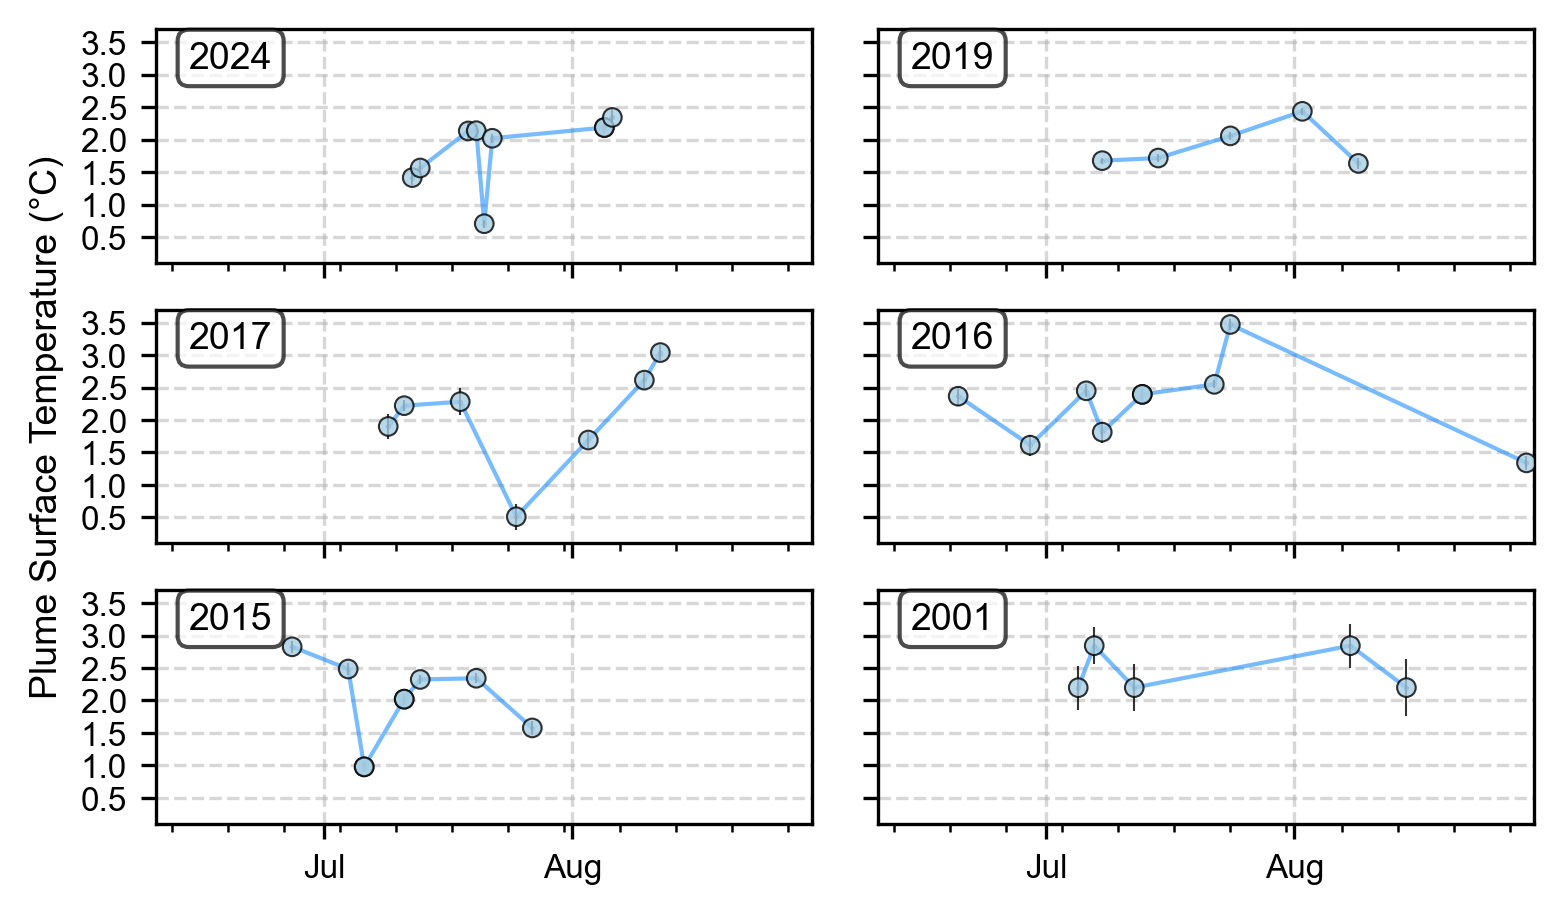


Seasonal variation plot complete!
Year 2024: N=8, SST Range: 1.41 to 2.34°C (Width: 0.93°C)
Year 2019: N=5, SST Range: 1.63 to 2.44°C (Width: 0.80°C)
Year 2017: N=7, SST Range: 0.51 to 3.04°C (Width: 2.53°C)
Year 2016: N=9, SST Range: 1.34 to 3.47°C (Width: 2.13°C)
Year 2015: N=9, SST Range: 0.98 to 2.83°C (Width: 1.85°C)
Year 2001: N=5, SST Range: 2.20 to 2.84°C (Width: 0.65°C)

Average SST Range for years with >=3 observations: 1.48°C


In [83]:
# Get top 6 years
top_years_index = timeseries_clean['date'].dt.year.value_counts().head(6).index

# Reverse order to plot most recent year first
top_years = sorted(top_years_index, reverse=True)

fig_width_mm = 135
fig_height_mm = 80  # Adjust height as needed
inches_per_mm = 0.0393701
fig, axs = plt.subplots(3, 2, figsize=(fig_width_mm * inches_per_mm, fig_height_mm * inches_per_mm), dpi=300)
plt.rcParams['font.size'] = 10

axs = axs.flatten()

for i, year in enumerate(top_years):
    # Filter data for the year
    year_data = timeseries_clean[timeseries_clean['date'].dt.year == year].copy()
    year_data = year_data.sort_values('date')
    
    # if year==2024:
    #     year_data = year_data[year_data['SST_median'] >= 1.0]
    # Scatter plot with sensor colors
    sns.scatterplot(data=year_data, x='date', y='SST_median', hue='landsat_sensor',
                    palette='Paired', s=20, edgecolor='black', linewidth=0.5, ax=axs[i], alpha=0.8, zorder=4)
    axs[i].plot(year_data['date'], year_data['SST_median'], 
            color='dodgerblue', linewidth=1, alpha=0.6, zorder=2)
    
    # REMOVE legend for individual plots
    legend = axs[i].get_legend()
    if legend is not None:
        legend.remove()
    
    # Add error bars
    axs[i].errorbar(year_data['date'], year_data['SST_median'], 
                    yerr=year_data['SST_stdDev'], fmt='o', color='black', 
                    alpha=0.8, markersize=0.1, capsize=0, elinewidth=0.5, zorder=3)
    
    # # if year is 2015, add carroll mooring data for that year
    # if year == 2015:
    #     axs[i].scatter(carroll_mooring_data['date'], carroll_mooring_data['temp'], 
    #                    color='red', s=15, label='Carroll Mooring', zorder=5)
    #     axs[i].plot(carroll_mooring_data['date'], carroll_mooring_data['temp'], 
    #                 color='red', linewidth=1, zorder=5)
    
 
    # Set y-axis limits
    axs[i].set_ylim(0.1, 3.7)
    # set y ticks at 0.1, 1.5, 2, 2.5, 3, 3.5
    axs[i].set_yticks([0.5, 1.0, 1.5, 2, 2.5, 3, 3.5])
    axs[i].set_yticklabels(['0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '3.5'])
    # Set xlim from June 30 to August 20
    axs[i].set_xlim(pd.to_datetime(f'{year}-06-10'), pd.to_datetime(f'{year}-08-31'))
    
    # Set ylabel
    axs[i].set_ylabel('Plume Surface Temperature (°C)', fontsize=9)
    
    # Format x-axis
    axs[i].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    axs[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    axs[i].xaxis.set_minor_locator(mdates.DayLocator(interval=7))
    # set fontsize of x-axis labels
    axs[i].tick_params(axis='x', which='major', labelsize=8)

    # set ytick label size
    axs[i].tick_params(axis='y', which='major', labelsize=8)
    
    # Set xlabel to none
    axs[i].set_xlabel('')
    
    # Keep legend for now (will add one legend at the end)
    
    # Hide x-axis labels for top plots only include for bottom row
    if i < 4:
        axs[i].set_xticklabels([])

    # only include y label for left plots
    if i % 2 == 1:
        axs[i].set_yticklabels([])

    # only include y axis label for the left middle plot
    if i == 2:
        axs[i].set_ylabel('Plume Surface Temperature (°C)', fontsize=9)
    else:
        axs[i].set_ylabel('')
    
    # Add year text box
    axs[i].text(0.05, 0.95, f'{year}', transform=axs[i].transAxes,
                fontsize=9, va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Remove ylabel for right plots
    if i % 2 == 1:
        axs[i].set_ylabel('')
    
    # Add grid
    axs[i].grid(True, linestyle='--', alpha=0.5)
    
    # Print SST range for the year
    min_sst = year_data['SST_median'].min()
    max_sst = year_data['SST_median'].max()
    sst_range = max_sst - min_sst

# Adjust layout
plt.tight_layout()
# decrease space between subplots
plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.show()

print("\nSeasonal variation plot complete!")

# for 2024 remove values less than 1.0

timeseries_clean['date'].dt.year.value_counts().head(20).index
# FOR YEARS WITH MORE THAN THREE DATA POINTS, PRINT THE MEAN RANGE
sst_range_values = []
for year in top_years:
# if 2024 remove values less than 1.0
    if year == 2024:
        year_data = timeseries_clean[(timeseries_clean['date'].dt.year == year) & (timeseries_clean['SST_median'] >= 1.0)]
    else:   
        year_data = timeseries_clean[timeseries_clean['date'].dt.year == year]
    if len(year_data) >= 3:
        min_sst = year_data['SST_median'].min()
        max_sst = year_data['SST_median'].max()
        sst_range = max_sst - min_sst
        print(f"Year {year}: N={len(year_data)}, SST Range: {min_sst:.2f} to {max_sst:.2f}°C (Width: {sst_range:.2f}°C)")

        # append to list
        sst_range_values.append(sst_range)

average_range = np.mean(sst_range_values)
print(f"\nAverage SST Range for years with >=3 observations: {average_range:.2f}°C")

C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\2769420008.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['-1.0', '-0.5', '0.0', '0.5', '1.0'])
C:\Users\s1834371\AppData\Local\Temp\ipykernel_27816\2769420008.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


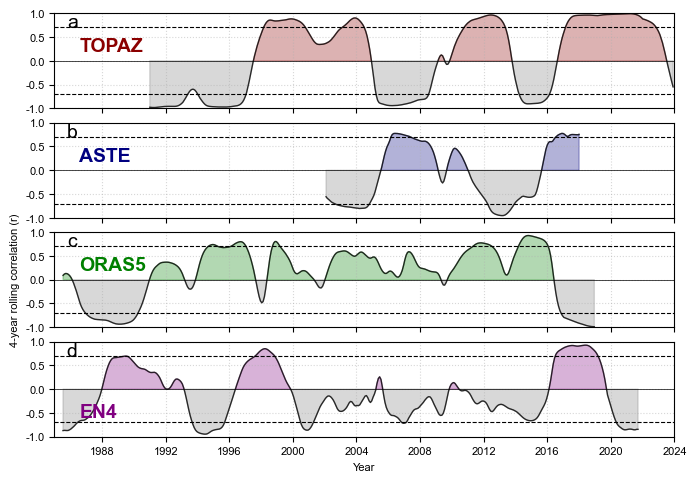

In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

# --- Configuration ---
window_years = 4
window_months = window_years * 12
# Common x-limits to ensure all plots align perfectly
xlims = (pd.Timestamp('1990-01-01'), pd.Timestamp('2024-01-01'))

models = {
    'TOPAZ': {'data': topaz_smoothed, 'color': 'darkred'},  # Red
    'ASTE':  {'data': aste_smoothed,  'color': 'navy'},  # Navy
    'ORAS5': {'data': oras5_smoothed, 'color': 'green'},   # Green
    'EN4':   {'data': en4_smoothed,   'color': 'purple'}  # Purple
}

# --- Helper ---
def to_decimal_year(dates):
    if hasattr(dates, 'dt'): d = dates.dt
    else: d = dates
    return d.year + (d.dayofyear - 1) / 365.25

# --- Plotting ---
# Create 4 subplots stacked vertically, sharing the X and Y axis
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 5.5), 
                         sharex=True, sharey=True, 
                         gridspec_kw={'hspace': 0.15})

# Pre-calculate Landsat interpolator
landsat_decimal = to_decimal_year(pred_dates)
f_landsat = interp1d(landsat_decimal, gpr_trend, bounds_error=False, fill_value=np.nan)

for (name, info), ax in zip(models.items(), axes):
    # 1. Data Prep (Same as your code)
    model_series = info['data']
    model_decimal = to_decimal_year(model_series.index)
    landsat_at_model_time = f_landsat(model_decimal)
    
    df_pair = pd.DataFrame({
        'Model': model_series.values,
        'Landsat': landsat_at_model_time
    }, index=model_series.index)
    
    # 2. Rolling Correlation
    rolling_r = df_pair['Model'].rolling(
        window=window_months, center=True, min_periods=window_months//2
    ).corr(df_pair['Landsat'])
    
    # 3. Plot Line
    ax.plot(rolling_r.index, rolling_r, color='k', linewidth=1, alpha=0.8)
    
    # 4. THE VISUAL TRICK: Fill Between
    # Fill green/blue where correlation is positive
    ax.fill_between(rolling_r.index, 0, rolling_r, where=(rolling_r >= 0),
                    color=info['color'], alpha=0.3, interpolate=True, label='Positive Corr')
    # Fill red/gray where correlation is negative (Inverse agreement)
    ax.fill_between(rolling_r.index, 0, rolling_r, where=(rolling_r < 0),
                    color='gray', alpha=0.3, interpolate=True, label='Negative Corr')

    # add a dotted line at +/-0.7
    ax.axhline(0.7, color='k', linestyle='--', linewidth=0.8)
    ax.axhline(-0.7, color='k', linestyle='--', linewidth=0.8)

    # Formatting per subplot
    ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
    if name=='ORAS5':
        ax.set_ylabel("4-year rolling correlation (r)")
    else:
        ax.set_ylabel("")
    # Adjust text position for EN4
    text_y = 0.2 if name == 'EN4' else 0.6
    ax.text(0.04, text_y, name, transform=ax.transAxes, fontweight='bold', fontsize=14, color=info['color'])
    ax.set_ylim(-1, 1)
    ax.set_yticklabels(['-1.0', '-0.5', '0.0', '0.5', '1.0'])
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.grid(True, linestyle=':', alpha=0.5)

axes[0].text(0.02, 0.85, "a", transform=axes[0].transAxes, fontsize=14)
axes[1].text(0.02, 0.85, "b", transform=axes[1].transAxes, fontsize=14)
axes[2].text(0.02, 0.85, "c", transform=axes[2].transAxes, fontsize=14)
axes[3].text(0.02, 0.85, "d", transform=axes[3].transAxes, fontsize=14)

xlims = (pd.Timestamp('1985-01-01'), pd.Timestamp('2024-01-01'))
for ax in axes:
    ax.set_xlim(xlims)

# Overall Formatting
plt.xlabel("Year")
plt.tight_layout()
plt.subplots_adjust(hspace=0.25) # Remove gap between plots
#savefigure
plt.savefig(FIGURES_DIR / 'rolling_correlation_plume_temp_models_landsat.png', dpi=300, bbox_inches='tight')
plt.show()

In [75]:
from scipy import stats
import pandas as pd
import numpy as np

def calculate_trend_since(dates, values, start_year=2017, end_year=2023, name="Dataset"):
    # 1. Convert inputs to pandas for easier handling
    dates = pd.to_datetime(dates)
    values = np.array(values)
    
    # 2. Filter for data from start_year onwards
    if isinstance(dates, pd.DatetimeIndex):
        mask = (dates.year >= start_year) & (dates.year <= end_year)
    else:
        mask = (dates.dt.year >= start_year) & (dates.dt.year <= end_year)
        
    subset_dates = dates[mask]
    subset_values = values[mask]
    
    if len(subset_values) < 2:
        print(f"{name}: Not enough data to calculate trend.")
        return
    
    # 3. Convert dates to Decimal Years (so slope is in Â°C/year)
    # Formula: Year + (DayOfYear / 365.25)
    if hasattr(subset_dates, 'dt'):
        decimal_years = subset_dates.dt.year + (subset_dates.dt.dayofyear - 1) / 365.25
    else:
        decimal_years = subset_dates.year + (subset_dates.dayofyear - 1) / 365.25
        
    # 4. Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(decimal_years, subset_values)
    
    print(f"{name} Trend ({start_year}-Present):")
    print(f"  Slope: {slope:+.4f} °C/year")
    print(f"  Total Change: {slope * (decimal_years.max() - decimal_years.min()):+.2f} °C (over {decimal_years.max() - decimal_years.min():.1f} years)")
    print(f"  R²: {r_value**2:.2f}, p-value: {p_value:.8f}")
    print("-" * 30)
    
    return slope

# --- Calculate for Landsat ---
# Uses 'pred_dates' and 'gpr_trend' from your GPR function
landsat_slope = calculate_trend_since(pred_dates, gpr_trend, start_year=2016, name="Landsat (GPR)")

# --- Calculate for TOPAZ ---
# Uses 'topaz_smoothed' (assuming it's a Series with DatetimeIndex)
topaz_slope = calculate_trend_since(topaz_smoothed.index, topaz_smoothed.values, start_year=2016, name="TOPAZ")

# --- Calculate for ASTE ---
aste_slope = calculate_trend_since(aste_smoothed.index, aste_smoothed.values, start_year=2016, name="ASTE")

# --- Calculate for ORAS5 ---

oras5_slope = calculate_trend_since(oras5_smoothed.index, oras5_smoothed.values, start_year=2016, name="ORAS5")    
print(f"Difference in rates (Landsat vs EN4): {diff:.4f} °C/year")

diff = abs(landsat_slope - en4_slope)

# --- Calculate for EN4 ---if landsat_slope is not None and en4_slope is not None:

en4_slope = calculate_trend_since(en4_smoothed.index, en4_smoothed.values, start_year=2016, name="EN4")    
print(f"Difference in rates (Landsat vs TOPAZ): {diff:.4f} °C/year")

diff = abs(landsat_slope - topaz_slope)

# --- Compare ---if landsat_slope is not None and topaz_slope is not None:

Landsat (GPR) Trend (2016-Present):
  Slope: -0.0941 °C/year
  Total Change: -0.74 °C (over 7.9 years)
  R²: 0.90, p-value: 0.00000000
------------------------------
TOPAZ Trend (2016-Present):
  Slope: -0.1101 °C/year
  Total Change: -0.87 °C (over 7.9 years)
  R²: 0.98, p-value: 0.00000000
------------------------------
ASTE Trend (2016-Present):
  Slope: -0.0397 °C/year
  Total Change: -0.08 °C (over 2.0 years)
  R²: 0.36, p-value: 0.00119067
------------------------------
ORAS5 Trend (2016-Present):
  Slope: +0.0849 °C/year
  Total Change: +0.25 °C (over 2.9 years)
  R²: 0.53, p-value: 0.00000053
------------------------------
Difference in rates (Landsat vs EN4): -0.4242 °C/year


NameError: name 'en4_slope' is not defined

## Summary

This simplified notebook contains:

1. **Data Loading**: All ocean reanalysis models (TOPAZ, ASTE, ORAS5) and Landsat plume temperatures
2. **Grounding Line Mapping**: Plume locations mapped to grounding line with heatmap, density plot, and histogram filtering
3. **Main Time Series**: Comprehensive plot with all datasets, GPR trends, and bootstrap confidence intervals
4. **Interannual Anomalies**: Separate figure showing temperature anomalies relative to long-term mean
5. **Temperature Distributions**: Histogram comparing all temperature distributions
6. **Interannual Variability**: Annual means and standard deviations sampled at Landsat observation times

In [ ]:
# create plotly plot of plume surface temperature time series
import plotly.express as px
fig = px.scatter(timeseries_clean, x='date', y='SST_median', 
                 color='landsat_sensor', 
                 error_y='SST_stdDev',
                 labels={'date': 'Date', 'SST_median': 'Plume Surface Temperature (°C)', 'landsat_sensor': 'Landsat Sensor'},
                 title='Plume Surface Temperature Time Series from Landsat',
                 hover_data={'date': True, 'SST_median': ':.2f', 'SST_stdDev': ':.2f', 'landsat_sensor': True})
fig.update_traces(marker=dict(size=6, line=dict(width=0.5, color='DarkSlateGrey')), opacity=0.7)

# show
fig.show()